# Ch01

## bandit

In [22]:
import numpy as np

class Bandit:

    def __init__(self, arms=10):
        self.rates = np.random.rand(arms)

    def play(self, arm):
        if np.random.rand() > self.rates[arm]:
            return 0
        return 1

bandit = Bandit()
bandit.play(0)

1

### Agent

In [185]:
class Agent:

    def __init__(self, epsilon, action_size=10):
        self.epsilon = epsilon
        self.Qs = [0] * action_size
        self.Ns = [0] * action_size

        # 记录探索次数
        self.counter = 0
        
    def update(self, action, reward):
        self.Ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) / self.Ns[action]
        
    def get_action(self):
        if np.random.rand() < self.epsilon:
            self.counter += 1
            return np.random.randint(0, len(self.Qs))
        return np.argmax(self.Qs)

### Run

7946 2927


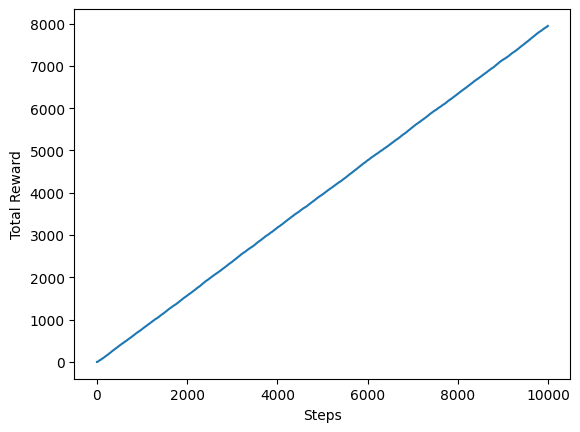

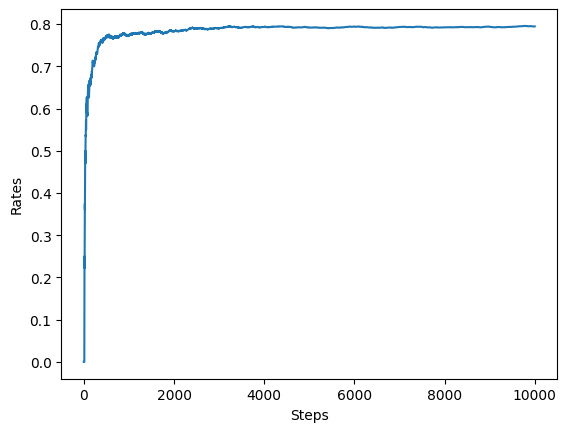

In [196]:
import matplotlib.pyplot as plt

steps = 10000
epsilon = 0.3

bandit = Bandit()
agent = Agent(epsilon)
total_reward = 0
total_rewards = []
rates = []

for step in range(steps):
    action = agent.get_action()
    reward = bandit.play(action)
    agent.update(action, reward)

    total_reward += reward
    total_rewards.append(total_reward)
    rates.append(total_reward / (step + 1))

print(total_reward, agent.counter)

plt.ylabel('Total Reward')
plt.xlabel('Steps')
plt.plot(total_rewards)
plt.show()

plt.ylabel('Rates')
plt.xlabel('Steps')
plt.plot(rates)
plt.show()

### Agent Avg

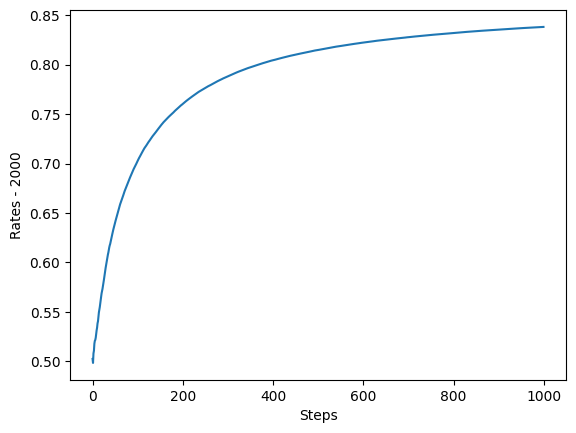

In [193]:
import matplotlib.pyplot as plt

runs = 2000
steps = 1000
epsilon = 0.1
all_rates = np.zeros((runs, steps))

for run in range(runs):
    bandit = Bandit()
    agent = Agent(epsilon)
    
    total_reward = 0
    rates = []
    
    for step in range(steps):
        action = agent.get_action()
        reward = bandit.play(action)
        agent.update(action, reward)
    
        total_reward += reward
        total_rewards.append(total_reward)
        rates.append(total_reward / (step + 1))

    # numpy 是复制, 列表就是改引用
    all_rates[run] = rates

plt.ylabel(f'Rates - {runs}')
plt.xlabel('Steps')
plt.plot(np.average(all_rates, axis=0))
plt.show()

## Non-Stationary Bandit

In [211]:
class NonStatBandit:

    def __init__(self, arms=10):
        self.rates = np.random.rand(arms)

    def play(self, arm):
        self.rates[arm] += 0.1 * np.random.randn()
        if np.random.rand() < self.rates[arm]:
            return 1
        return 0

### AlphaAgent

In [214]:
class AlphaAgent:

    def __init__(self, epsilon, alpha, action_size=10):
        self.epsilon = epsilon
        self.alpha = alpha
        self.Qs = [0] * action_size
        self.Ns = [0] * action_size

        # 记录探索次数
        self.counter = 0
        
    def update(self, action, reward):
        self.Ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) * self.alpha
        
    def get_action(self):
        if np.random.rand() < self.epsilon:
            self.counter += 1
            return np.random.randint(0, len(self.Qs))
        return np.argmax(self.Qs)

### 当作稳态问题处理

7050 3085


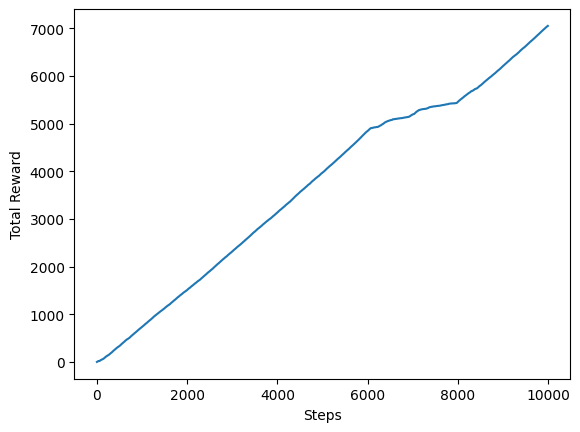

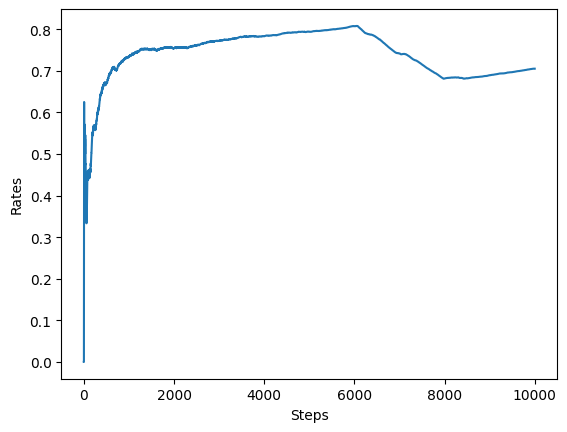

In [209]:
import matplotlib.pyplot as plt

steps = 10000
epsilon = 0.3

bandit = NonStatBandit()
agent = Agent(epsilon)
total_reward = 0
total_rewards = []
rates = []

for step in range(steps):
    action = agent.get_action()
    reward = bandit.play(action)
    agent.update(action, reward)

    total_reward += reward
    total_rewards.append(total_reward)
    rates.append(total_reward / (step + 1))

print(total_reward, agent.counter)

plt.ylabel('Total Reward')
plt.xlabel('Steps')
plt.plot(total_rewards)
plt.show()

plt.ylabel('Rates')
plt.xlabel('Steps')
plt.plot(rates)
plt.show()

### 当作非稳态问题处理

7984 2994


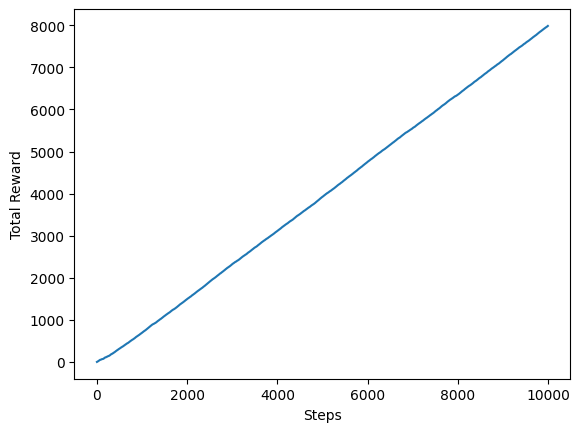

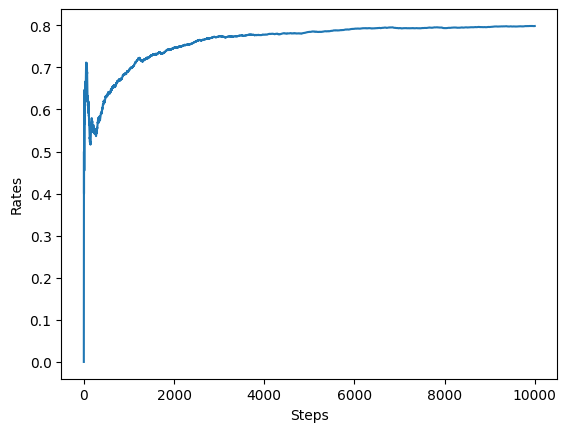

In [218]:
import matplotlib.pyplot as plt

steps = 10000
epsilon = 0.3
alpha = 0.8

bandit = NonStatBandit()
agent = AlphaAgent(epsilon, alpha)
total_reward = 0
total_rewards = []
rates = []

for step in range(steps):
    action = agent.get_action()
    reward = bandit.play(action)
    agent.update(action, reward)

    total_reward += reward
    total_rewards.append(total_reward)
    rates.append(total_reward / (step + 1))

print(total_reward, agent.counter)

plt.ylabel('Total Reward')
plt.xlabel('Steps')
plt.plot(total_rewards)
plt.show()

plt.ylabel('Rates')
plt.xlabel('Steps')
plt.plot(rates)
plt.show()

# Ch04

## 迭代策略评估算法

In [3]:
V = {'L1': 0.0, 'L2': 0.0}
new_V = V.copy()

for _ in range(100):
    V['L1'] = 0.5 * (-1 + 0.9 * new_V['L1']) + 0.5 * (1 + 0.9 * new_V['L2'])
    V['L2'] = 0.5 * (0 + 0.9 * new_V['L1']) + 0.5 * (-1 + 0.9 * new_V['L2'])
    new_V = V.copy()

print(V)

{'L1': -2.2499335965027827, 'L2': -2.7499335965027827}


In [7]:
# 设置阈值自动停止
V = {'L1': 0.0, 'L2': 0.0}
new_V = V.copy()

counter = 0
while True:
    V['L1'] = 0.5 * (-1 + 0.9 * new_V['L1']) + 0.5 * (1 + 0.9 * new_V['L2'])
    V['L2'] = 0.5 * (0 + 0.9 * new_V['L1']) + 0.5 * (-1 + 0.9 * new_V['L2'])
    counter += 1
    
    delta = abs(V['L1'] - new_V['L1'])
    delta = max(delta, abs(V['L2'] - new_V['L2']))
    if delta < 0.000001:
        break
    
    new_V = V.copy()

print(counter, V)

119 {'L1': -2.2499910298721737, 'L2': -2.7499910298721737}


In [8]:
# 通过覆盖的方式实现
# 设置阈值自动停止
V = {'L1': 0.0, 'L2': 0.0}

counter = 0
while True:
    t = 0.5 * (-1 + 0.9 * V['L1']) + 0.5 * (1 + 0.9 * V['L2'])
    delta = abs(V['L1'] - t)
    V['L1'] = t
    
    t = 0.5 * (0 + 0.9 * V['L1']) + 0.5 * (-1 + 0.9 * V['L2'])
    delta = max(delta, abs(V['L2'] - t)) 
    V['L2'] = t
    
    counter += 1
    
    if delta < 0.000001:
        break

print(counter, V)

93 {'L1': -2.24999380622831, 'L2': -2.749994224006975}


## GridWorld

In [17]:
import numpy as np

class GridWorld:

    def __init__(self):
        self.action_space = [0, 1, 2, 3]
        self.action_meaning = {
            0: 'UP',
            1: 'DOWN',
            2: 'LEFT',
            3: 'RIGHT'
        }

        self.reward_map = np.array(
            [
                [0, 0, 0, 1],
                [0, None, 0, -1],
                [0, 0, 0, 0]
            ]
        )

        self.goal_state = (0, 3)
        self.wall_state = (1, 1)
        self.start_state = (2, 0)

        self.agent_state = self.start_state

    @property
    def height(self):
        return len(self.reward_map)

    @property
    def width(self):
        return len(self.reward_map[0])

    @property
    def shape(self):
        return self.reward_map.shape

    def actions(self):
        return self.action_space

    def states(self):
        for h in range(self.height):
            for w in range(self.width):
                # return 是一锤子买卖
                # yield 就是走走停停
                yield (h, w) # 迭代器对象

    def next_state(self, state, action):
        # 计算移动目的地
        action_move_map = [
            (-1, 0),
            (1, 0),
            (0, -1),
            (0, 1)
        ]
        move = action_move_map[action]
        next_state = (state[0] + move[0], state[1] + move[1])
        ny, nx = next_state

        # 判断移动结果
        if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height:
            next_state = state
        elif next_state == self.wall_state:
            next_state = state

        return next_state

    def reward(self, state, action, next_state):
        # if state == next_state:
        #     # 防止重复获得奖励或炸弹
        #     return 0
        return self.reward_map[next_state]

    def step(self, action):
        state = getattr(self, 'state', self.start_state)
        next_state = self.next_state(state, action)
        
        self.state = next_state
        reward = self.reward(state, action, next_state)

        done = False
        if next_state == self.goal_state:
            done = True
        
        return next_state, reward, done

    def reset(self):
        self.state = self.start_state
        return self.state
        

In [60]:
def eval_onestep(pi, V, env, gamma=0.9):
    # 覆盖式
    for state in env.states():
        # 终点状态价值为 0
        if state == env.goal_state or state == env.wall_state:
            V[state] = 0
            continue

        # probabilities
        action_probs = pi[state]
        new_V = 0

        for action, action_prob in action_probs.items():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)

            new_V += action_prob * (r + gamma * V[next_state])
        
        V[state] = new_V

    return V

# 迭代策略评估算法
def policy_eval(pi, V, env, gamma, threshold=0.001):
    while True:
        old_V = V.copy()
        V = eval_onestep(pi, V, env, gamma)

        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t
        if delta < threshold:
            break
    return V

In [43]:
from collections import defaultdict

env = GridWorld()
gamma = 0.9
# 状态价值函数
V = defaultdict(lambda: 0)
# 策略
pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})

V = policy_eval(pi, V, env, gamma)
print(V)

defaultdict(<function <lambda> at 0x7e48055ea020>, {(0, 0): 0.03028806099856353, (1, 0): -0.026936362355998215, (0, 1): 0.0977824241089171, (0, 2): 0.2071980803453905, (1, 2): -0.49597815123565897, (0, 3): 0, (2, 0): -0.09886155432366783, (1, 1): 0, (2, 2): -0.43435951415465596, (1, 3): -0.37134421613448265, (2, 3): -0.7838088155423875, (2, 1): -0.21729033457922942})


## 贪婪策略

In [1]:
# 根据当前的状态价值函数获得"当前最优策略"
def greedy_policy(V, env, gamma):
    pi = {}

    for state in env.states():
        action_values = {}

        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values[action] = value
        # max 作用于字典则默认使用 key 来比较, 这里修改key为键值
        # key 参数作用: 
        # 在比较这些元素之前，先对每个元素调用这个函数，用函数的返回值来比大小
        max_action = max(action_values, key=action_values.get)
        action_probs = {0: 0, 1: 0, 2: 0, 3: 0}
        action_probs[max_action] = 1
        pi[state] = action_probs
    
    return pi

In [50]:
from collections import defaultdict

def policy_iter(env, gamma, threshold=0.001):
    pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
    V = defaultdict(lambda: 0)

    while True:
        V = policy_eval(pi, V, env, gamma, threshold)
        new_pi = greedy_policy(V, env, gamma)

        if new_pi == pi:
            # 一直更新到最优, 否则不停
            break

        pi = new_pi

    print(V)
    return pi

In [46]:
env = GridWorld()
gamma = 0.9

pi = policy_iter(env, gamma)

print(pi)

defaultdict(<function policy_iter.<locals>.<lambda> at 0x7e4804ba6980>, {(0, 0): 0.81, (1, 0): 0.7290000000000001, (0, 1): 0.9, (0, 2): 1.0, (1, 2): 0.9, (0, 3): 0, (2, 0): 0.6561000000000001, (1, 1): 0, (2, 2): 0.81, (1, 3): 1.0, (2, 3): 0.7290000000000001, (2, 1): 0.7290000000000001})
{(0, 0): {0: 0, 1: 0, 2: 0, 3: 1}, (0, 1): {0: 0, 1: 0, 2: 0, 3: 1}, (0, 2): {0: 0, 1: 0, 2: 0, 3: 1}, (0, 3): {0: 1, 1: 0, 2: 0, 3: 0}, (1, 0): {0: 1, 1: 0, 2: 0, 3: 0}, (1, 1): {0: 1, 1: 0, 2: 0, 3: 0}, (1, 2): {0: 1, 1: 0, 2: 0, 3: 0}, (1, 3): {0: 1, 1: 0, 2: 0, 3: 0}, (2, 0): {0: 1, 1: 0, 2: 0, 3: 0}, (2, 1): {0: 0, 1: 0, 2: 0, 3: 1}, (2, 2): {0: 1, 1: 0, 2: 0, 3: 0}, (2, 3): {0: 0, 1: 0, 2: 1, 3: 0}}


## 价值迭代法

In [57]:
def value_iter_onestep(V, env, gamma):
    for state in env.states():
        if state == env.goal_state:
            V[state] = 0
            continue

        action_values = []
        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values.append(value)

        V[state] = max(action_values)
    return V

In [58]:
def value_iter(env, gamma, threshold=0.001):
    V = defaultdict(lambda: 0)
    
    while True:
        old_V = V.copy()
        V = value_iter_onestep(V, env, gamma)

        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t
        if delta < threshold:
            break
    return V

In [54]:
env = GridWorld()
gamma = 0.9

V = value_iter(env, gamma)
pi = greedy_policy(V, env, gamma)
print(V, pi)

defaultdict(<function value_iter.<locals>.<lambda> at 0x7e4804223e20>, {(0, 0): 0.81, (1, 0): 0.7290000000000001, (0, 1): 0.9, (0, 2): 1.0, (1, 2): 0.9, (0, 3): 0, (2, 0): 0.6561000000000001, (2, 1): 0.7290000000000001, (1, 1): 0.81, (2, 2): 0.81, (1, 3): 1.0, (2, 3): 0.7290000000000001}) {(0, 0): {0: 0, 1: 0, 2: 0, 3: 1}, (0, 1): {0: 0, 1: 0, 2: 0, 3: 1}, (0, 2): {0: 0, 1: 0, 2: 0, 3: 1}, (0, 3): {0: 1, 1: 0, 2: 0, 3: 0}, (1, 0): {0: 1, 1: 0, 2: 0, 3: 0}, (1, 1): {0: 1, 1: 0, 2: 0, 3: 0}, (1, 2): {0: 1, 1: 0, 2: 0, 3: 0}, (1, 3): {0: 1, 1: 0, 2: 0, 3: 0}, (2, 0): {0: 1, 1: 0, 2: 0, 3: 0}, (2, 1): {0: 0, 1: 0, 2: 0, 3: 1}, (2, 2): {0: 1, 1: 0, 2: 0, 3: 0}, (2, 3): {0: 0, 1: 0, 2: 1, 3: 0}}


# Ch5

In [2]:
import numpy as np

def sample(dices=2):
    x = 0
    for _ in range(dices):
        x += np.random.choice([1, 2, 3, 4, 5, 6])
    return x

In [24]:
trial = 1000

samples = []

for _ in range(trial):
    samples.append(sample())
    
V = sum(samples) / len(samples)

print(V)

7.095


In [47]:
# 增量式
trial = 1000

V = 0

for i in range(trial):
    V = V + (sample() - V) / (i + 1)

print(V)

6.918999999999998


## RandomAgent

In [53]:
from collections import defaultdict

class RandomAgent:

    def __init__(self):
        self.gamma = 0.9
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)
        self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def eval(self):
        G = 0
        for data in reversed(self.memory):
            state, action, reward = data
            G = self.gamma * G + reward
            self.cnts[state] += 1
            self.V[state] += (G - self.V[state]) / self.cnts[state]

        return

In [55]:
# 蒙特卡洛方法
env = GridWorld()
agent = RandomAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.eval()
            break

        state = next_state

print(agent.V)

defaultdict(<function RandomAgent.__init__.<locals>.<lambda> at 0x79dce6b919e0>, {(1, 3): -0.38975892772334386, (2, 3): -0.7720025410162557, (1, 2): -0.47819795766812145, (2, 2): -0.4346573018738972, (2, 1): -0.2124899863929764, (2, 0): -0.09998987260938359, (1, 0): -0.03999146740026476, (0, 0): 0.022063645210141265, (0, 1): 0.09062487221550576, (0, 2): 0.20297799963476051})


In [72]:
# 策略迭代法(DP)
env = GridWorld()
agent = RandomAgent()

V = policy_eval(agent.pi, agent.V, env, 0.9)

print(V)

defaultdict(<function RandomAgent.__init__.<locals>.<lambda> at 0x79dce6b87920>, {(0, 0): 0.03028806099856353, (1, 0): -0.026936362355998215, (0, 1): 0.0977824241089171, (0, 2): 0.2071980803453905, (1, 2): -0.49597815123565897, (0, 3): 0, (2, 0): -0.09886155432366783, (1, 1): 0, (2, 2): -0.43435951415465596, (1, 3): -0.37134421613448265, (2, 3): -0.7838088155423875, (2, 1): -0.21729033457922942})


## McAgent

In [18]:
import numpy as np
from collections import defaultdict

class McAgent:

    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1
        self.alpha = 0.1
        self.action_size = 4

        # 初始状态下, 策略随机
        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        for data in reversed(self.memory):
            state, action, reward = data
            G = self.gamma * G + reward
            key = (state, action)
            self.cnts[key] += 1
            
            self.Q[key] += (G - self.Q[key]) * self.alpha

            # 更新策略
            # 通过贪婪化逐步逼近最优点
            self.pi[state] = epsilon_greedy_probs(self.Q, state, self.epsilon)

In [7]:
# one-hot
def greedy_probs(Q, state, action_size=4):
    qs = [Q[state, action] for action in range(action_size)]
    max_action = np.argmax(qs)

    action_probs = {action: 0.0 for action in range(action_size)}
    action_probs[max_action] = 1
    return action_probs

# epsilon-greedy
def epsilon_greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[state, action] for action in range(action_size)]
    max_action = np.argmax(qs)

    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

In [112]:
# 蒙特卡洛方法
env = GridWorld()
agent = McAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

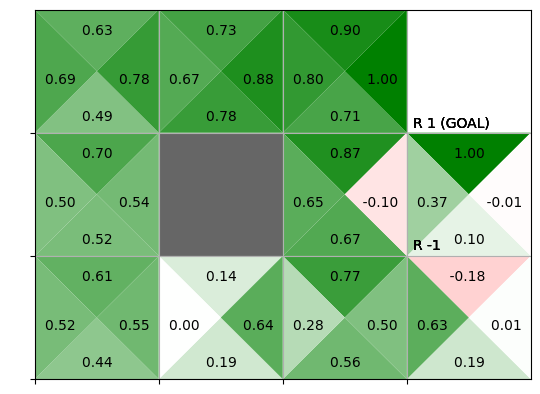

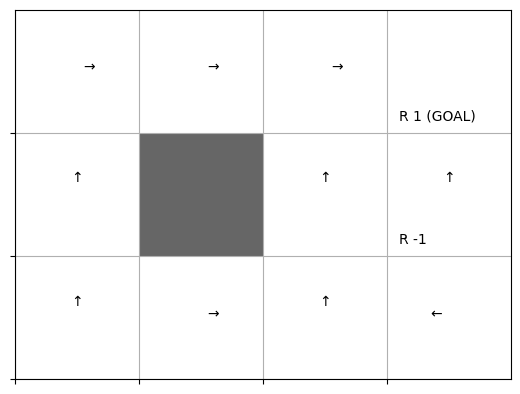

In [115]:
# Render
from DeepLearining4_Render import *

render = Renderer(env.reward_map, env.goal_state, env.wall_state)
render.render_q(agent.Q)

## 重要性采样

In [3]:
import numpy as np

x = np.array([1, 2, 3])
pi = np.array([0.1, 0.1, 0.8])

# 期望
e = np.sum(x * pi)
print('E_pi[x]', e)

# 蒙特卡洛
n = 100
samples = []
for _ in range(n):
    s = np.random.choice(x, p=pi)
    samples.append(s)

mean = np.mean(samples)
var = np.var(samples)
print(f'MC: {mean:.2f} (var: {var:.2f})')

E_pi[x] 2.7
MC: 2.72 (var: 0.40)


In [16]:
# 重要性采样
x = np.array([1, 2, 3])
b = np.array([1/3, 1/3, 1/3])

n = 100
samples = []
for _ in range(n):
    idx = np.arange((len(b)))
    i = np.random.choice(idx, p=b)
    s = x[i]
    rho = pi[i] / b[i]
    samples.append(rho * s)

mean = np.mean(samples)
var = np.var(samples)
print(f'IS: {mean:.2f} (var: {var:.2f})')

IS: 3.09 (var: 10.80)


# Ch06

In [3]:
from collections import defaultdict

class TdAgent:

    def __init__(self):
        self.gamma = 0.9
        self.alpha= 0.01
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def eval(self, state, reward, next_state, done):
        next_V = 0 if done else self.V[next_state]
        target = reward + self.gamma * next_V

        self.V[state] += (target - self.V[state]) * self.alpha

In [5]:
env = GridWorld()
agent = TdAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.eval(state, reward, next_state, done)
        if done:
            break
        state = next_state

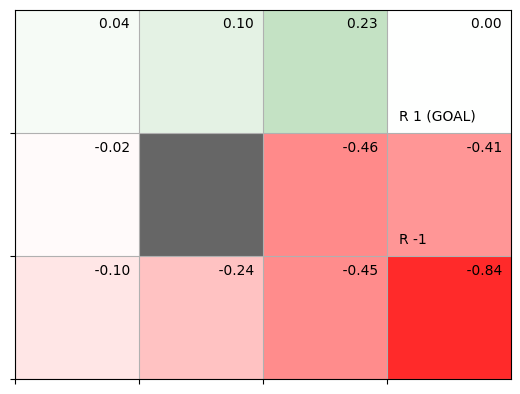

In [6]:
# Render
from DeepLearining4_Render import *

render = Renderer(env.reward_map, env.goal_state, env.wall_state)
render.render_v(agent.V)

## On-Policy SARSA

In [7]:
from collections import defaultdict, deque

class SarsaAgent:

    def __init__(self):
        self.gamma = 0.9
        # 1 - alpha = 0.2 这指数移动平均权重递减是不是太高了?
        self.alpha = 0.8
        # epsilon-greedy
        self.epsilon = 0.1 
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)
        
    def get_action(self, state):
        action_probs = self.pi[state]
        action = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(action, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        next_q = 0 if done else self.Q[next_state, next_action]
        target = reward + self.gamma * next_q
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = epsilon_greedy_probs(self.Q, state, self.epsilon)

In [28]:
env = GridWorld()
agent = SarsaAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)
        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

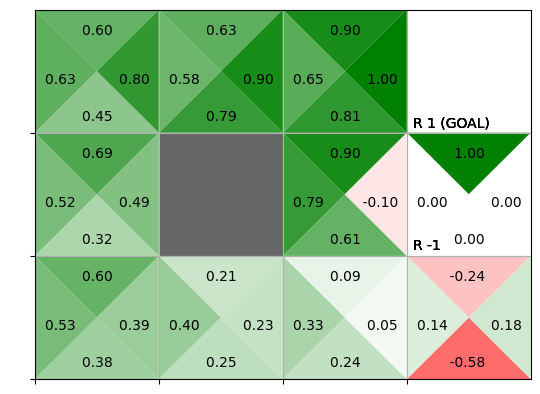

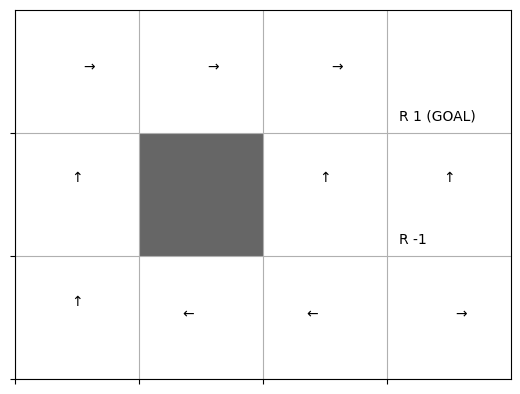

In [29]:
# Render
from DeepLearining4_Render import *

render = Renderer(env.reward_map, env.goal_state, env.wall_state)
render.render_q(agent.Q)

## Off-Policy Sarsa

In [41]:
class SarsaOffPolicyAgent:

    def __init__(self):
        # 状态价值函数的衰减
        self.gamma = 0.9
        # 学习率
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        if done:
            next_q = 0
            rho = 1
        else:
            next_q = self.Q[next_state, next_action]
            rho = self.pi[next_state][next_action] / self.b[next_state][next_action]
        
        # 对 pi 进行更新, b 本质上是为 pi 服务的, 因此不独立再计算一个 b
        target = rho * (reward + self.gamma * next_q)
        # target = reward + rho * self.gamma * next_q
        
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = epsilon_greedy_probs(self.Q, state, 0)
        self.b[state] = epsilon_greedy_probs(self.Q, state, self.epsilon)

In [58]:
env = GridWorld()
agent = SarsaOffPolicyAgent()

episodes = 1000000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)
        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

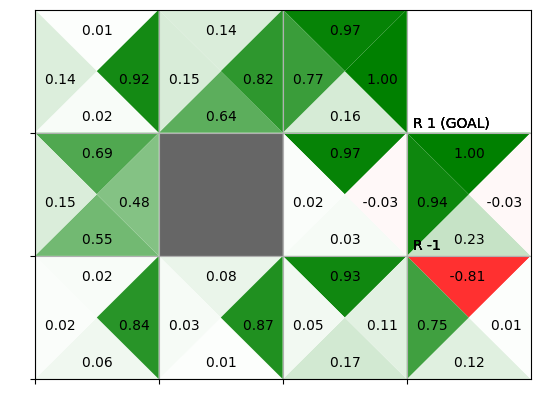

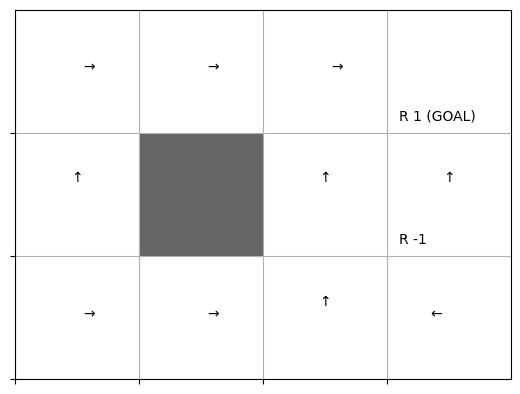

In [59]:
# Render
from DeepLearining4_Render import *

render = Renderer(env.reward_map, env.goal_state, env.wall_state)
render.render_q(agent.Q)

### Other

In [49]:
class OtherSarsaOffPolicyAgent:

    def __init__(self):
        # 状态价值函数的衰减
        self.gamma = 0.9
        # 学习率
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        if done:
            next_q = 0
            rho = 1
        else:
            next_q = self.Q[next_state, next_action]
            rho = self.pi[next_state][next_action] / self.b[next_state][next_action]
        
        # 对 pi 进行更新, b 本质上是为 pi 服务的, 因此不独立再计算一个 b
        # target = rho * (reward + self.gamma * next_q)
        target = reward + rho * self.gamma * next_q
        
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = epsilon_greedy_probs(self.Q, state, 0)
        self.b[state] = epsilon_greedy_probs(self.Q, state, self.epsilon)

In [56]:
env = GridWorld()
agent = OtherSarsaOffPolicyAgent()

episodes = 1000000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)
        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

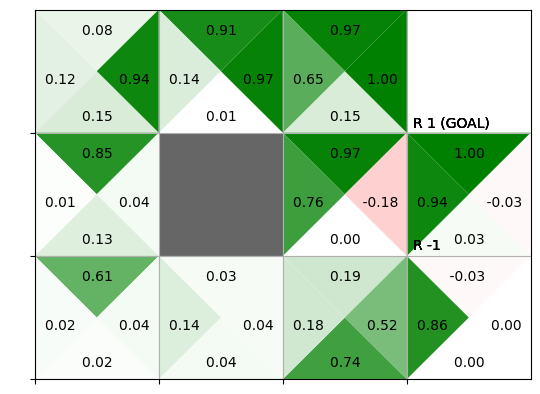

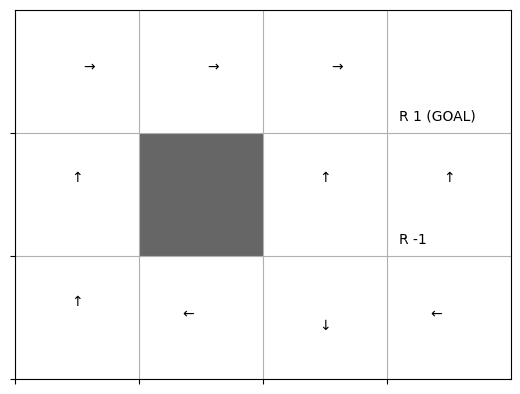

In [57]:
# Render
from DeepLearining4_Render import *

render = Renderer(env.reward_map, env.goal_state, env.wall_state)
render.render_q(agent.Q)

按理说这两个的期望是一致的, 因为 reward 和 S' 完全独立, 但期望是期望, 我们只能通过大数定律证得无限接近.

## Q-Learning

In [8]:
from collections import defaultdict
import numpy as np

class QLearningAgent:

    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.b[state]
        action = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(action, p=probs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = epsilon_greedy_probs(self.Q, state, epsilon=0)
        self.b[state] = epsilon_greedy_probs(self.Q, state, epsilon=self.epsilon)

In [9]:
env = GridWorld()
agent = QLearningAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done)
        if done:
            break
        state = next_state

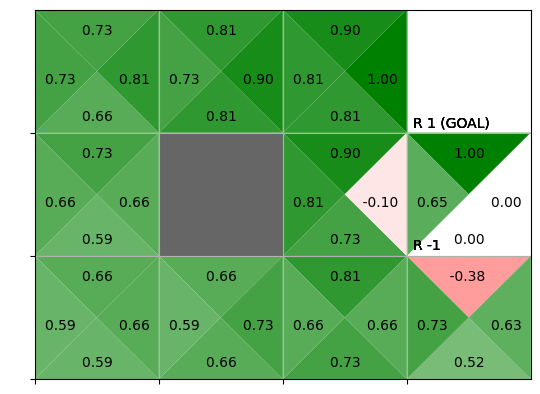

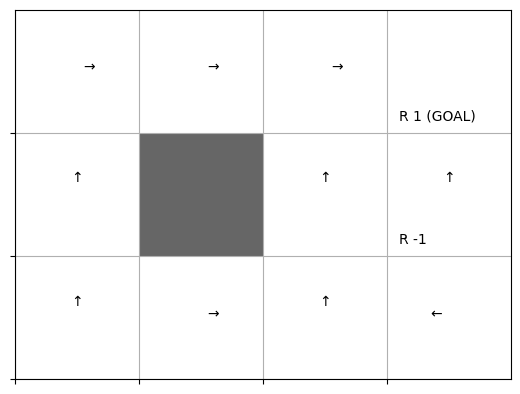

In [10]:
# Render
from DeepLearining4_Render import *

render = Renderer(env.reward_map, env.goal_state, env.wall_state)
render.render_q(agent.Q)

## 样本模型版 Q-Learning

In [ ]:
class QLearninigAgent:
    
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            qs = [self.Q[next_state, a] for a in range(self.action_size)]
            return np.argmax(qs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = self.gamma * next_q_max + reward
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha


# Ch07

In [4]:
import numpy as np

# 将状态编码为向量
def one_hot(state):
    HEIGHT, WIDTH = 3, 4
    vec = np.zeros(HEIGHT * WIDTH, dtype=np.float32)
    y, x = state
    idx = WIDTH * y + x
    vec[idx] = 1.0
    return vec[np.newaxis, :] # 批量操作, 这里创建一个新轴

print(one_hot((1, 0)))

[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]


Dezero太古老了, 要回退 numpy 才能用, 干脆之间上 pytorch 了

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class QNet(nn.Module):

    def __init__(self):
        super().__init__()

        # 12 种状态
        self.l1 = nn.Linear(12, 100)
        # 4 种动作空间
        self.l2 = nn.Linear(100, 4)

    def forward(self, x):
        x = torch.relu(self.l1(x))
        x = self.l2(x)
        return x

qnet = QNet()

state = (2, 0)
state = torch.Tensor(one_hot(state))

qs = qnet(state)
print(qs)


tensor([[-0.1051,  0.0727, -0.0067,  0.0585]], grad_fn=<AddmmBackward0>)


In [50]:
import torch.optim as optim

class QLearningAgent:

    def __init__(self):
        self.gamma = 0.9
        # 神经网络的lr 和 EMA 的 1 - epsilon 有啥关系
        self.lr = 0.01
        self.epsilon = 0.1
        self.action_size = 4

        self.qnet = QNet()
        self.optimizer = optim.SGD(
            self.qnet.parameters(),
            lr=self.lr
        )

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            qs = self.qnet(state)
            return torch.argmax(qs, dim=1)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q = torch.zeros(1)
        else:
            next_qs = self.qnet(next_state)
            next_q = torch.max(next_qs, dim=1).values

        target = self.gamma * next_q + reward
        target = target.reshape(-1, 1)
        
        qs = self.qnet(state)
        q = qs[:, action]
        loss = F.mse_loss(q.reshape(-1, 1), target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss.item()    

In [51]:
env = GridWorld()
agent = QLearningAgent()

episodes = 1000
loss_history = []

for episode in range(episodes):
    state = env.reset()
    state = torch.Tensor(one_hot(state))

    total_loss, cnt = 0, 0
    done = False

    while not done:
        action = agent.get_action(torch.Tensor(state))
        next_state, reward, done = env.step(action)
        next_state = torch.Tensor(one_hot(next_state))

        loss = agent.update(state, action, reward, next_state, done)
        total_loss += loss
        cnt += 1
        state = next_state

    average_loss = total_loss / cnt
    loss_history.append(average_loss)

In [64]:
Q = {}

for state in env.states():
    state_ = one_hot(state)
    state_ = torch.Tensor(state_)
    for idx, q in enumerate(agent.qnet(state_).tolist()[0]):  
        Q[state, idx] = q

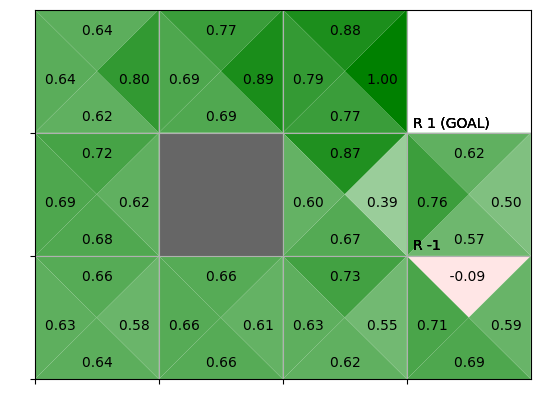

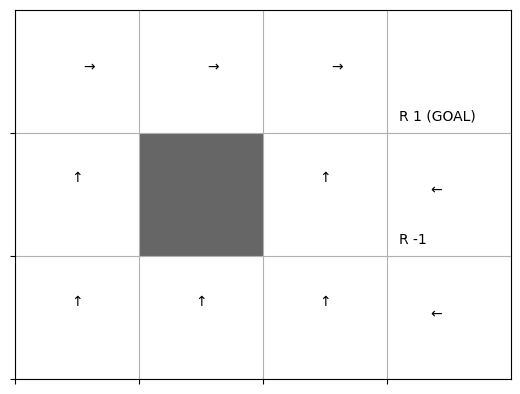

In [66]:
# Render
from DeepLearining4_Render import *

render = Renderer(env.reward_map, env.goal_state, env.wall_state)
render.render_q(Q)

# Ch08

In [70]:
import gym

env = gym.make('CartPole-v1')

state = env.reset()
# 推车的位置, 速度, 杆的角度, 角速度
print(state)

action_space = env.action_space
print(action_space)

(array([ 0.00116859, -0.01874659,  0.03312861,  0.01064522], dtype=float32), {})
Discrete(2)


In [88]:
import numpy as np
import gymnasium as gym

env = gym.make('CartPole-v1', render_mode='human')
state, info = env.reset()
done = False

while not done:
    # terminated：任务是否“自然结束”（比如杆子倒了）
    # truncated：是否因为时间上限被强制结束
    
    env.render()
    action = np.random.choice([0, 1])
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

print(f'杆子倒了 {terminated}', f'回合结束 {truncated}')
env.close()

杆子倒了 True 回合结束 False
